# IAPR: Final Project ‒ UNO Game State Recovery


**Group ID:** 46

**Author 1 (sciper):** Lemonnier Théo (312284)  
**Author 2 (sciper):** Desnos Edgar (388960)   
**Author 3 (sciper):** Anthonin Duval (355584)

## Imports and Configurations

In [1]:
from pathlib import Path

from src.token_detection import generate_pipeline_figure

In [2]:
TRAIN_IMAGES_PATH = Path("./data/iapr-26-uno-vision-challenge/train_images")

## Card Detection (Hybrid): 

Card detection is implemented as **two interchangeable backends** sharing a common interface — this is what the project name *hybrid* refers to. Both backends are queried through the same orchestrator (`src/orchestrator.py`) and return a list of the same dataclass, `CardDetection` (`src/detection.py`):

- `quad` — the four corner points of the card (full polygon for the classical backend, the corner bbox rectangle for YOLO),
- `corner_crops` — 1 or 2 RGB 80x80 crops fed to the CNN,
- `body_mask` — boolean mask of the pixels where the card color should be sampled,
- `centroid` — `(x, y)` used for player-zone assignment,
- `source` — `"classical"` or `"yolo"`, kept for logging and debugging,
- `confidence` — YOLO confidence, `None` for classical.

Because both backends share this contract, `process_image_with_detections` is completely backend-agnostic: player-zone assignment, center-card detection, the CNN call and the color classifier all consume the same object, and the pipeline can be switched by passing a different `detect_fn` to `run_submission`.

### Classical Backend — Segmentation and Cropping

The classical branch (`src/segment_cards.py`, called from `src/classical_backend.py`) isolates cards from raw pixels with no learned weights. The image is converted to HLS and only the saturation channel is kept: card bodies are strongly saturated relative to the background, so a Gaussian blur followed by an `inRange` threshold on saturation produces a clean binary mask. The threshold is slightly lower on the white background (`15`) than on the noisy one (`30`) because cards stand out more easily against the white. A morphological closing with a 5x5 elliptical kernel fills in small holes caused by symbols printed on the cards.

External contours are then extracted; anything below 40000 pixels of area is discarded (tokens, hands, noise). Each remaining contour is simplified with `cv2.approxPolyDP` at a 3% perimeter tolerance, collapsing the outline to a 4-point quadrilateral. From each quad we derive the three downstream attributes of `CardDetection`:

- the **centroid**, used by player-zone assignment,
- a **body mask** (slightly eroded to stay safely inside the card), used by the HSV color classifier,
- two **corner crops** obtained by warping the card to a canonical 200x310 rectangle and resizing the top-left and bottom-right corners to 80x80 RGB patches — the exact input format expected by the CNN.

This backend is robust on the white background and easy to debug because every step is interpretable.

### YOLO Backend — Body-Mask Ring Trick

The YOLO backend (`src/yolo_backend.py`) wraps an Ultralytics YOLO model trained to detect the card's **corner symbol bbox** — not the full card outline. It is faster and more reliable on the noisy leafy background, where saturation thresholding starts to over-segment.

The fact that YOLO only returns the corner bbox is a problem for the color classifier, which needs to vote on a region that contains the printed card color rather than the symbol itself. Sampling inside the corner bbox would mostly capture digits/icons and miss the card body. To solve this without running a second segmenter on top of YOLO, the body mask is built as a **ring around the corner bbox**: an outer rectangle padded by `1.5 ×` the bbox side, an inner rectangle padded by `0.2 ×` the bbox side, and the mask is the difference of the two — true in the annulus, false everywhere else. This carves out a band of pixels just *outside* the symbol corner, where the card body is guaranteed to be visible, while excluding the symbol and most of the background. The HSV color classifier then runs unchanged on this mask, exactly as it does for the classical backend's full-card mask.

## Color Filtering

Color classification is also fully classical (`src/color_classifier.py`, `src/detect_reference.py`). For each input image we compute five HSV masks — Yellow, Red, Blue, Green and Black — using hand-tuned ranges. Red wraps around the HSV hue cylinder, so it is built as the union of two separate ranges (low hue and high hue).

To label a card we restrict each color mask to the card's body mask returned by the segmenter, count the number of mask pixels that fall inside, and pick the color with the most votes. This is robust to the printed symbol pixels because they only account for a small fraction of the card body. The four returned labels are mapped to the submission alphabet `{r, g, b, y}`.

Two symbol classes (`wild` and `+4`) are color-agnostic by the rules of the game, so when the CNN predicts one of those we skip the color step entirely and emit the symbol on its own.

## Symbol Recognition with a CNN

Recognising the digits and action symbols (`0`–`9`, `+2`, `+4`, `wild`, `skip`, `reverse` — 15 classes total) is the part of the pipeline where a learned model clearly outperforms a classical approach, because of the visual variety of the symbols and of the printing/lighting conditions.

We trained a small VGG-style CNN (`hybric_detection_utils/train_uno.py`, class `UnoSymbolCNN`): four convolutional blocks with batch normalisation, global average pooling and a linear head, for about 4.8M parameters — well under the 12M cap of the competition. Inputs are 80x80 RGB crops normalised with the standard ImageNet mean/std. The training crops are generated by the same corner-extraction routine used at inference (`extract_corner_crops`), which guarantees that train and test distributions match.

At inference time (`src/card_labeler.predict_card`) we run the CNN on the two corner crops of each card (top-left and bottom-right corner indices). UNO cards repeat the same symbol in both corners, so we keep the prediction with the higher softmax confidence. The resulting symbol is then concatenated with the color label from the HSV pipeline (`submission_label` in `src/class_maps.py`) to form the final card string.

## Player Zone Assignment

Once all cards are detected, we still need to decide which card belongs to which player and which one is the center card. This is handled by `src/player_zones.py`.

The four player zones are not hard-coded in pixels but loaded from `data/jetons_et_backgrounds/backgrounds/bbox_player_position.csv`, which stores `(posx, posy, width, height)` for each player on the reference background. We convert those rectangles into **fractional coordinates** (relative to the reference image width and height) so the same zones can be reused on any image size — assignment then only depends on a card's centroid expressed as a fraction of the image.

The **center ROI** is derived geometrically from the four player zones: it spans horizontally between player 4's right edge and player 2's left edge, and vertically between player 3's bottom edge and player 1's top edge — i.e. the empty region in the middle of the table. If that computation ever degenerates (e.g. inconsistent CSV), we fall back to a centered 40%-60% rectangle.

The full assignment in `process_image_with_detections` works as follows:
1. `detect_center` keeps the unique detection whose centroid is inside the center ROI — if zero or more than one card falls there, we declare no center card (empty `center_card`).
2. All remaining detections are passed to `assign_hands`, which tests each centroid against the four player rectangles and groups detections by player.
3. Each per-player list is labelled by the CNN+color pipeline and joined with `;` into the final `player_X_cards` field; if a player has no card we emit `"EMPTY"`, matching the submission format.

## Background-Aware Segmentation

The same mean-saturation signal that decides which active-player token to look for is reused inside the classical card detector. In `src/classical_backend.py` the very first step calls `detect_background(image_bgr)`, which returns `"white"` or `"noisy"` based on the average saturation of the image. The result is passed straight to `segment_cards(image_bgr, background_kind=...)`, which then picks the appropriate saturation threshold (`15` for the white background, `30` for the noisy leafy one — see `src/segment_cards.py`).

This single, cheap, image-level statistic therefore drives two independent decisions:
1. **Card segmentation threshold** in the classical detection backend.
2. **Active-player token type** (yellow disc vs. black rectangle) in the token detector.

Keeping a single background-classification primitive shared between both subsystems avoids drift and ensures the pipeline reacts coherently to whichever scene type the image belongs to.

## Model Analysis

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

csv_path = Path("./model/detect/train/results.csv")

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

display(df.head())
print(df.columns)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,lr/pg3,lr/pg4,lr/pg5,lr/pg6,lr/pg7
0,1,160.468,4.02042,17.14460,2.44763,0.08479,0.47337,0.10642,0.04882,1.80083,2.51292,1.09140,0.005990,0.001997,0.005990,0.001997,0.005990,0.001997,0.005990,0.001997
1,2,309.477,1.77372,2.74218,1.00764,0.30901,0.57721,0.37659,0.21753,1.39865,1.75646,0.94563,0.011989,0.003996,0.011989,0.003996,0.011989,0.003996,0.011989,0.003996
2,3,458.700,1.54843,2.03840,0.94399,0.53245,0.72316,0.61742,0.38498,1.24466,1.28665,0.90522,0.017983,0.005994,0.017983,0.005994,0.017983,0.005994,0.017983,0.005994
3,4,606.452,1.42635,1.59073,0.91794,0.67028,0.81324,0.76886,0.51681,1.11144,1.03082,0.87785,0.023967,0.007989,0.023967,0.007989,0.023967,0.007989,0.023967,0.007989
4,5,750.169,1.29507,1.19925,0.89063,0.87953,0.88162,0.94461,0.67764,0.97300,0.71881,0.85522,0.029938,0.009979,0.029938,0.009979,0.029938,0.009979,0.029938,0.009979


Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2', 'lr/pg3', 'lr/pg4', 'lr/pg5', 'lr/pg6',
       'lr/pg7'],
      dtype='str')


### 1. Loss curve
The training and validation losses show a consistent decreasing trend, indicating successful convergence of the model during optimization. A rapid reduction is observed during the early epochs, followed by a progressive stabilization as the model approaches a local optimum. 

Validation losses remain slightly lower than training losses throughout training. The relatively lower validation losses may be influenced by the smaller size of the validation set, which can reduce data variability and make the validation samples comparatively easier than the training distribution. The small gap between both curves and their similar evolution suggest good generalization performance, with no clear evidence of overfitting.

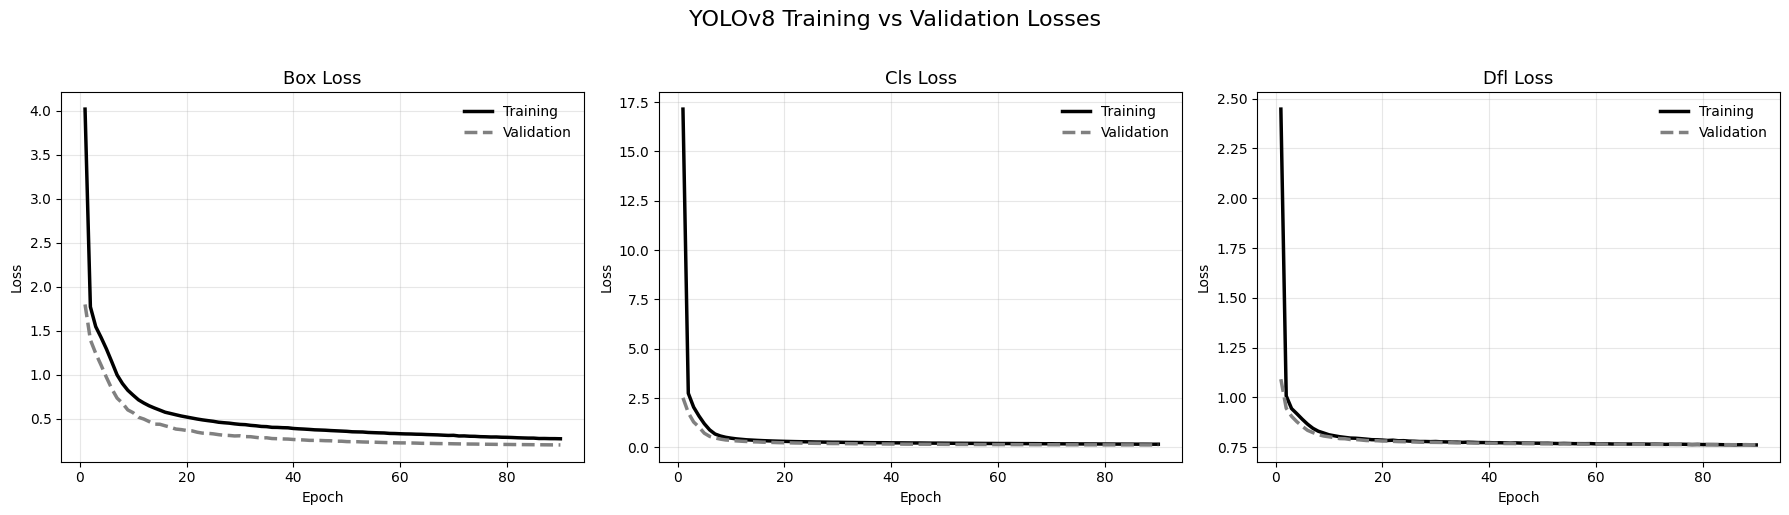

In [9]:
import matplotlib.pyplot as plt

loss_types = ["box_loss", "cls_loss", "dfl_loss"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, loss in zip(axes, loss_types):
    
    train_col = f"train/{loss}"
    val_col = f"val/{loss}"

    # Training en noir
    if train_col in df.columns:
        ax.plot(
            df["epoch"],
            df[train_col],
            color="black",
            linewidth=2.5,
            label="Training"
        )

    # Validation en gris
    if val_col in df.columns:
        ax.plot(
            df["epoch"],
            df[val_col],
            color="gray",
            linewidth=2.5,
            linestyle="--",
            label="Validation"
        )

    ax.set_title(loss.replace("_", " ").title(), fontsize=13)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")

    ax.grid(alpha=0.3)
    ax.legend(frameon=False)

plt.suptitle(
    "YOLOv8 Training vs Validation Losses",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

### 2. Precision, recall, mAP

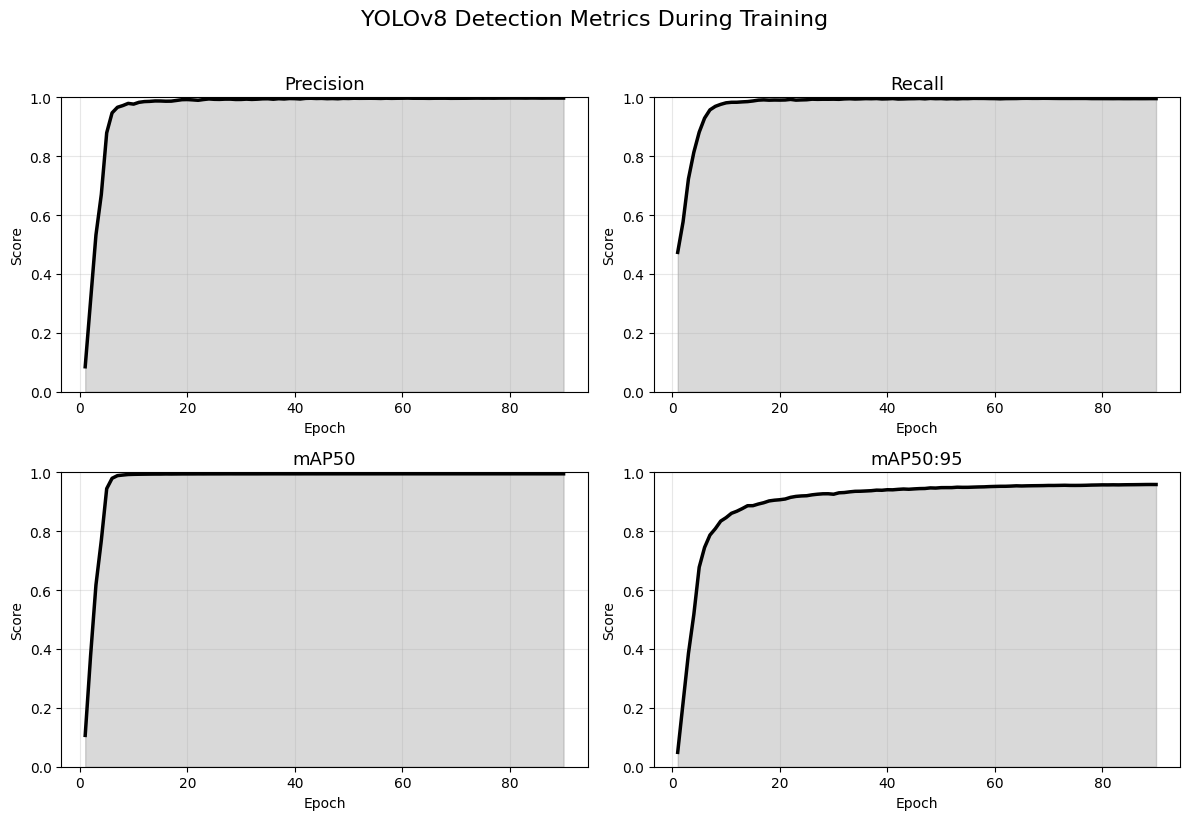

In [10]:
import matplotlib.pyplot as plt

metrics = {
    "metrics/precision(B)": "Precision",
    "metrics/recall(B)": "Recall",
    "metrics/mAP50(B)": "mAP50",
    "metrics/mAP50-95(B)": "mAP50:95"
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (col, title) in zip(axes, metrics.items()):

    if col in df.columns:

        ax.plot(
            df["epoch"],
            df[col],
            color="black",
            linewidth=2.5
        )

        # light area under curve
        ax.fill_between(
            df["epoch"],
            df[col],
            alpha=0.15,
            color="black"
        )

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")

    ax.grid(alpha=0.3)
    ax.set_ylim(0, 1)

plt.suptitle(
    "YOLOv8 Detection Metrics During Training",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

The detection metrics show rapid convergence during the first epochs, followed by a stabilization phase. Precision, recall, and mAP50 quickly approach values close to 1, indicating that the model rapidly learns to correctly identify and localize objects. The mAP50:95 metric increases more gradually, as it evaluates localization quality under stricter IoU thresholds. The smooth saturation of all metrics and the absence of performance degradation suggest stable training and good generalization capability.

### 3. Prediction on test images
Before Launching this cell, please make sure to have run the main.py to generate the /runs/detect/predict folder

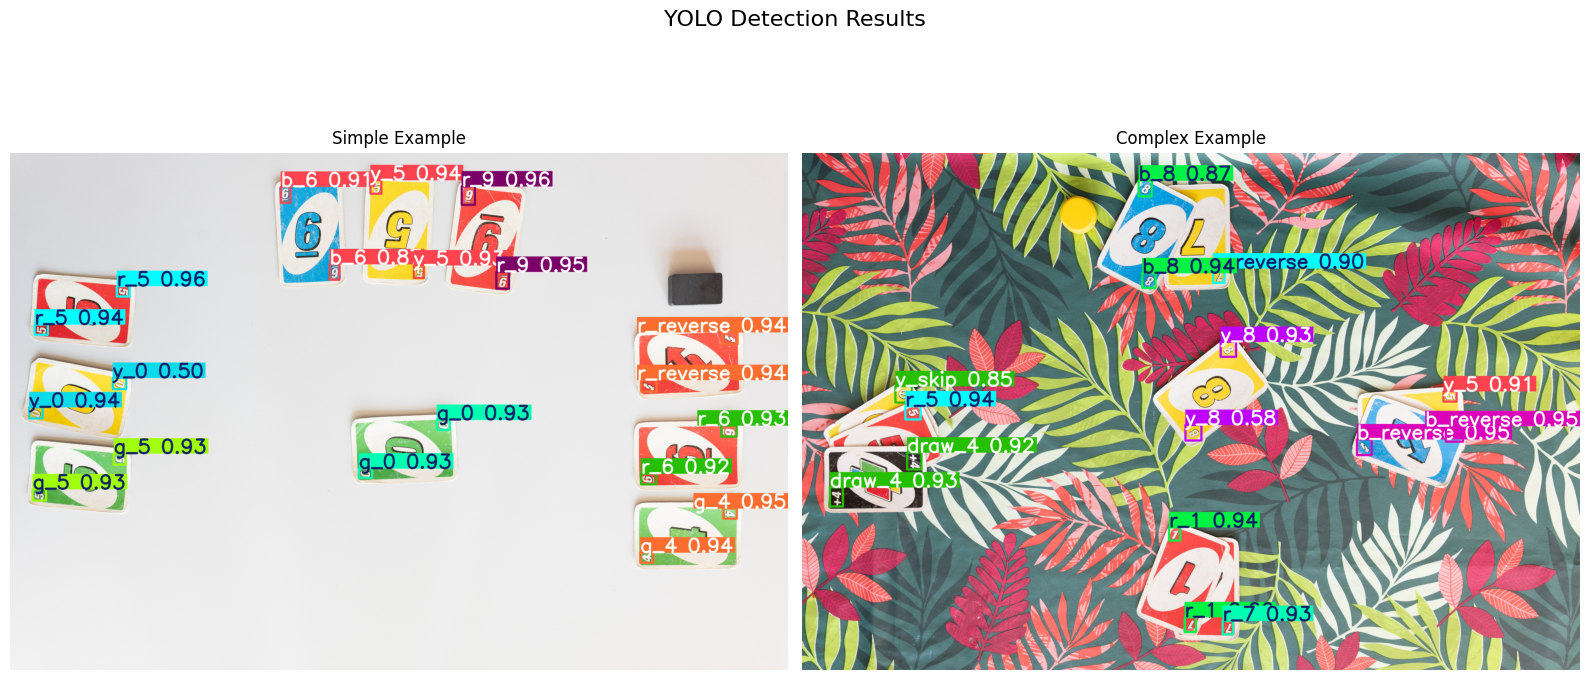

In [13]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

predict_folder = Path("./model/detection_examples")

# Choose images
simple_file = "L1000793.jpg"
complex_file = "L1001003.jpg"

img1 = Image.open(predict_folder / simple_file)
img2 = Image.open(predict_folder / complex_file)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Simple example
axes[0].imshow(img1)
axes[0].set_title("Simple Example")
axes[0].axis("off")

# More difficult example
axes[1].imshow(img2)
axes[1].set_title("Complex Example")
axes[1].axis("off")

plt.suptitle("YOLO Detection Results", fontsize=16)

plt.tight_layout()
plt.show()

The figure shows YOLO detection results on an unseen images from the original Kaggle dataset that was not used during training. The model successfully detects and localizes UNO cards under different orientations and positions, with most predictions associated with high confidence scores (>0.9), indicating strong prediction certainty. Correct detections are obtained even for partially rotated and partially occluded cards. Failure cases and prediction limitations are discussed separately.

### 4. Feature-map visualizations

In [15]:
from pathlib import Path
from ultralytics import YOLO

model_path = Path("./model/best.pt")
model = YOLO(model_path)

# Choose images
path_to_file = Path("./runs/detect/predict/L1000793.jpg")

model.predict(
    source=path_to_file,
    imgsz=960,
    conf=0.25,
    visualize=True
)


Saving C:\Users\edgar\Desktop\Homework\iapr_uno_competition\runs\detect\predict-2\L1000793\stage0_Conv_features.png... (32/32)
Saving C:\Users\edgar\Desktop\Homework\iapr_uno_competition\runs\detect\predict-2\L1000793\stage1_Conv_features.png... (32/64)
Saving C:\Users\edgar\Desktop\Homework\iapr_uno_competition\runs\detect\predict-2\L1000793\stage2_C2f_features.png... (32/64)
Saving C:\Users\edgar\Desktop\Homework\iapr_uno_competition\runs\detect\predict-2\L1000793\stage3_Conv_features.png... (32/128)
Saving C:\Users\edgar\Desktop\Homework\iapr_uno_competition\runs\detect\predict-2\L1000793\stage4_C2f_features.png... (32/128)
Saving C:\Users\edgar\Desktop\Homework\iapr_uno_competition\runs\detect\predict-2\L1000793\stage5_Conv_features.png... (32/256)
Saving C:\Users\edgar\Desktop\Homework\iapr_uno_competition\runs\detect\predict-2\L1000793\stage6_C2f_features.png... (32/256)
Saving C:\Users\edgar\Desktop\Homework\iapr_uno_competition\runs\detect\predict-2\L1000793\stage7_Conv_featur

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'b_0', 1: 'b_1', 2: 'b_2', 3: 'b_3', 4: 'b_4', 5: 'b_5', 6: 'b_6', 7: 'b_7', 8: 'b_8', 9: 'b_9', 10: 'b_draw_2', 11: 'b_reverse', 12: 'b_skip', 13: 'draw_4', 14: 'g_0', 15: 'g_1', 16: 'g_2', 17: 'g_3', 18: 'g_4', 19: 'g_5', 20: 'g_6', 21: 'g_7', 22: 'g_8', 23: 'g_9', 24: 'g_draw_2', 25: 'g_reverse', 26: 'g_skip', 27: 'r_0', 28: 'r_1', 29: 'r_2', 30: 'r_3', 31: 'r_4', 32: 'r_5', 33: 'r_6', 34: 'r_7', 35: 'r_8', 36: 'r_9', 37: 'r_draw_2', 38: 'r_reverse', 39: 'r_skip', 40: 'wild', 41: 'y_0', 42: 'y_1', 43: 'y_2', 44: 'y_3', 45: 'y_4', 46: 'y_5', 47: 'y_6', 48: 'y_7', 49: 'y_8', 50: 'y_9', 51: 'y_draw_2', 52: 'y_reverse', 53: 'y_skip'}
 obb: None
 orig_img: array([[[223, 221, 221],
         [220, 218, 218],
         [218, 216, 216],
         ...,
         [228, 231, 236],
         [228, 231, 236],
         [225, 228, 233]],
 
        [[221

Feature map visualizations provide insight into the information learned at different stages of the convolutional network. 

In early convolutional layers (Stage 0), filters extract low-level visual features such as edges, contours, color transitions, and simple textures. These basic patterns constitute the building blocks used by the network for processing, they visually resemble the structures highlighted after HSV thresholding
![stage0_Conv_features.png](attachment:stage0_Conv_features.png)

As the depth of the network increases, intermediate layers progressively combine these low-level representations into more meaningful structures such symbols, and numbers. 
![stage12_C2f_features.png](attachment:stage12_C2f_features.png)

In the final layers, feature maps become more abstract and focus on high-level semantic information corresponding to complete object characteristics, allowing the network to distinguish and localize UNO cards. The following visualizations illustrate this progressive transition from simple visual patterns to object-level representations.
![stage21_C2f_features.png](attachment:stage21_C2f_features.png)

note: Feature maps from convolution and C2f layers are shown as they represent complementary stages of feature processing. Convolution layers illustrate the extraction of basic visual patterns such as edges, textures, and local structures, whereas C2f layers provide insight into how these low-level features are progressively refined and combined into richer semantic representations. Their visualization therefore highlights the hierarchical feature learning process within YOLO.


### 5. Failure case analysis 

## Active Player Detection

To determine the active player, we implement a classical computer vision pipeline. This rule-based approach is chosen over deep learning because the active player tokens possess highly distinct, invariant shapes and colors compared to the standard game cards, making them computationally efficient to isolate.

### Background Classification

The dataset features two distinct environments, each utilizing a specific active player token:
- White Background: Employs a rectangular, black token.
- Leafy Background: Employs a circular, yellow token.

Because each token requires unique geometric and color filters, the pipeline first classifies the background by computing the mean saturation across the HSV color space of the entire image. Images with a mean saturation greater than $50$ are classified as leafy, while the remainder are classified as white.

### Token Localization Pipeline

Once the background and the target token is identified, the pipeline executes the following sequence:
1. Color Thresholding: The image is converted to the HSV color space and thresholded using predefined ranges to isolate pixels matching the target token's color profile (black or yellow).
2. Morphological Filtering: An opening operator removes small, isolated noise spikes (e.g., speckles on cards), followed by a closing operator to bridge micro-gaps and smooth the boundaries of the target blob masks.
3. Contour Filtering & Scoring: External contours are extracted. Candidate blobs are evaluated against known geometric priors of the token (area, circularity for the yellow token, aspect ratio and rectangularity for the black token). The highest-scoring candidate is selected.
4. Centroid Mapping: The center of mass (centroid) of the optimal contour is computed via image moments and mapped to the closest image quadrant to output the active player ID (1 to 4).

### Visual Pipeline Analysis

Below we illustrate the step-by-step intermediate transformations of our pipeline for both background modalities, proving the robustness of the HSV masks and morphological steps under varying conditions.

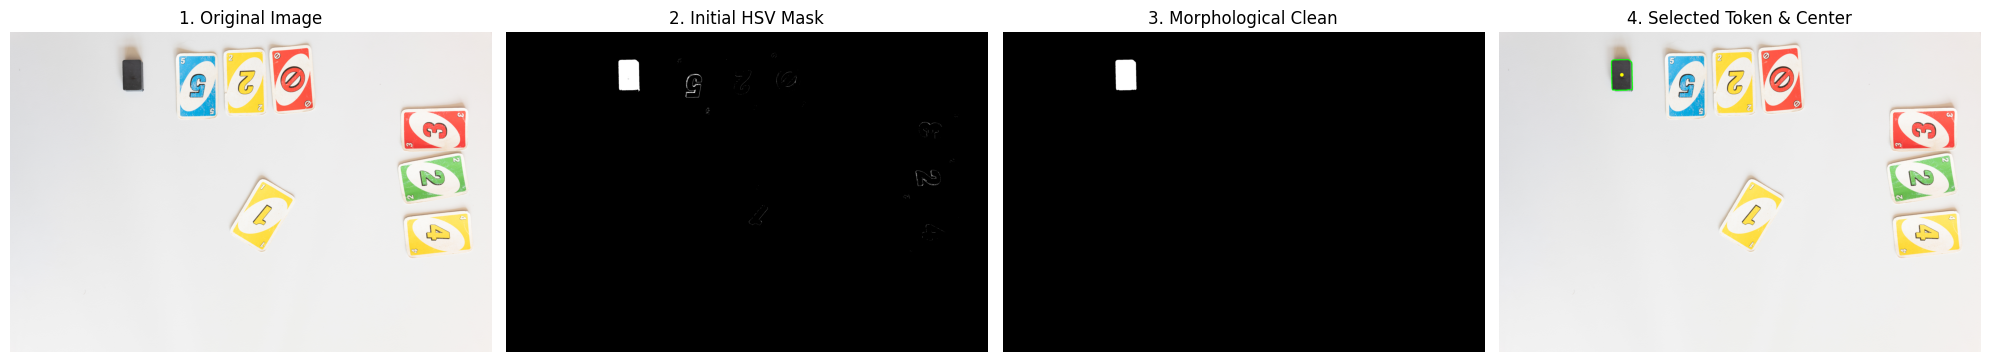

In [3]:
generate_pipeline_figure(TRAIN_IMAGES_PATH / "L1000770.jpg")

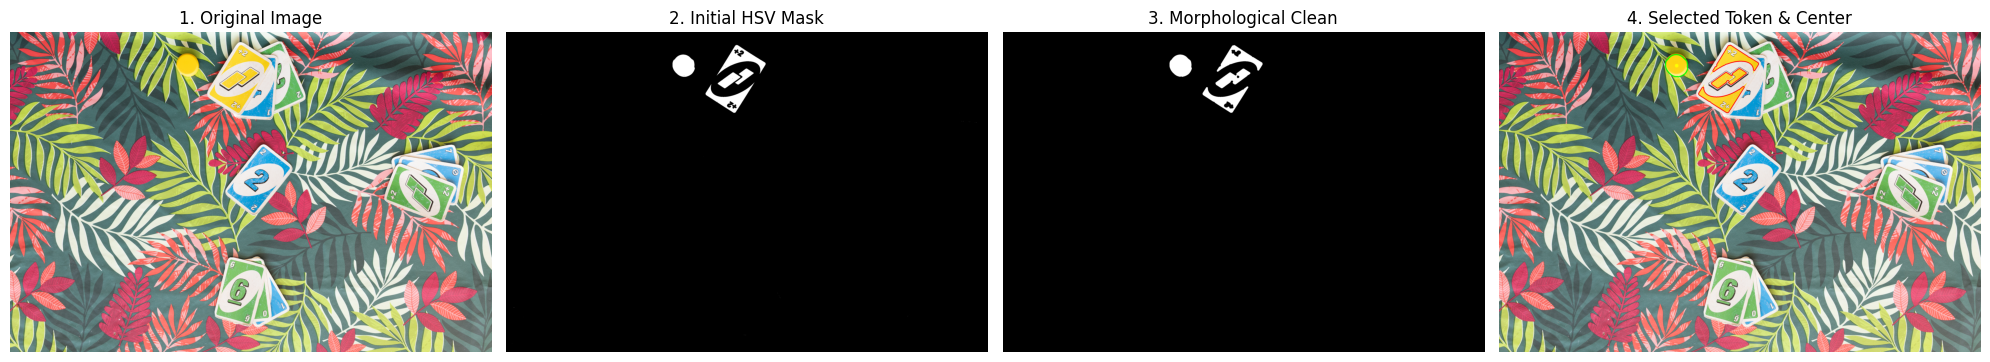

In [4]:
generate_pipeline_figure(TRAIN_IMAGES_PATH / "L1000973.jpg")